### Autor: **David Roca Tauste**
---

# Preparación

In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.calibration import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor

from joblib import dump, load

In [187]:
ruta = "datos_viviendas.xlsx"
datos = pd.read_excel(ruta)

In [188]:
print(datos.shape)
print(f"La cantidad de filas es: {datos.shape[0]}")
print(f"La cantidad de columnas es: {datos.shape[1]}")

(140, 21)
La cantidad de filas es: 140
La cantidad de columnas es: 21


In [189]:
datos.describe()

,josrosrod_dia,josrosrod_mes,josrosrod_año,ricmirber_longitud,josrosrod_lat,josrosrod_precio,rafmaralf_baños,samartlop_superficie,davroctau_planta,robripcon_habitaciones,elilopper_distanciaCentro
count,140.000000,140.000000,140.000000,140.000000,140.000000,1.400000e+02,140.000000,140.000000,140.000000,140.000000,140.000000
mean,15.657143,2.500000,2021.278571,-0.392414,39.452205,3.436194e+05,2.092857,128.064286,1.878571,3.314286,10.682000
std,6.150126,2.315105,10.702026,0.115302,0.141000,5.959285e+05,1.418766,76.409556,1.781067,1.469526,16.999879
min,1.000000,1.000000,1963.000000,-0.720000,39.061593,5.000000e+03,1.000000,12.000000,0.000000,1.000000,0.000000
25%,13.000000,2.000000,2025.000000,-0.415191,39.417375,1.450000e+05,1.000000,80.000000,1.000000,3.000000,3.000000
50%,16.000000,2.000000,2025.000000,-0.389500,39.440198,2.100000e+05,2.000000,102.000000,1.500000,3.000000,7.000000
75%,20.000000,2.000000,2025.000000,-0.349000,39.496900,2.962500e+05,2.000000,140.000000,3.000000,4.000000,9.452500
max,31.000000,12.000000,2025.000000,0.467111,39.823000,5.000000e+06,11.000000,430.000000,11.000000,10.000000,132.000000


In [190]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   josrosrod_origen           140 non-null    object 
 1   jorosrod_municipio         140 non-null    object 
 2   josrosrod_dia              140 non-null    int64  
 3   josrosrod_mes              140 non-null    int64  
 4   josrosrod_año              140 non-null    int64  
 5   ricmirber_longitud         140 non-null    float64
 6   josrosrod_lat              140 non-null    float64
 7   josrosrod_precio           140 non-null    int64  
 8   alvbelnav_iluminacion      140 non-null    object 
 9   davsoreng_duplex           140 non-null    object 
 10  alegarsal_terraza          140 non-null    object 
 11  rafmaralf_baños            140 non-null    int64  
 12  luctarcom_orientacion      139 non-null    object 
 13  samartlop_superficie       140 non-null    int64  

In [191]:
datos.head()

,josrosrod_origen,jorosrod_municipio,josrosrod_dia,josrosrod_mes,josrosrod_año,ricmirber_longitud,josrosrod_lat,josrosrod_precio,alvbelnav_iluminacion,davsoreng_duplex,...,rafmaralf_baños,luctarcom_orientacion,samartlop_superficie,davroctau_planta,juamarxxx_trastero,robripcon_habitaciones,omapasvac_ascensor,elilopper_distanciaCentro,rauramesc_airecentral,guifue_parking
0,Fotocasa,Benetuser,16,2,2025,-0.3950,39.4180,140000,Alta,0,...,1,Sureste,81,1,1,3,1,6.0,1,0
1,Fotocasa,Benetuser,16,2,2025,-0.3980,39.4170,85000,Alta,0,...,1,Este,161,1,0,1,0,7.0,1,0
2,Fotocasa,Benetuser,16,2,2025,-0.3987,39.4149,225000,Alta,0,...,2,Este,179,1,1,3,0,6.0,1,0
3,Fotocasa,Benetuser,16,2,2025,-0.3990,39.4145,129999,Alta,0,...,1,Sur,89,2,0,3,1,6.0,0,0
4,Fotocasa,Benetuser,16,2,2025,-0.3985,39.4133,145000,Baja,0,...,1,Oeste,55,1,0,1,1,6.0,1,0


---
# a) Análisis y preprocesamiento de datos

## 1. Gestión de valores nulos

In [192]:
print("Número de casillas nulas:")
datos.isnull().sum()

Número de casillas nulas:


josrosrod_origen             0
jorosrod_municipio           0
josrosrod_dia                0
josrosrod_mes                0
josrosrod_año                0
ricmirber_longitud           0
josrosrod_lat                0
josrosrod_precio             0
alvbelnav_iluminacion        0
davsoreng_duplex             0
alegarsal_terraza            0
rafmaralf_baños              0
luctarcom_orientacion        1
samartlop_superficie         0
davroctau_planta             0
juamarxxx_trastero           0
robripcon_habitaciones       0
omapasvac_ascensor           0
elilopper_distanciaCentro    0
rauramesc_airecentral        0
guifue_parking               0
dtype: int64

In [193]:
valores_nulos = datos.isnull().sum().sort_values(ascending=False)

# Añadimos "reset_index" para numerar las filas resultantes
ratio_nulos = (valores_nulos / len(datos)).reset_index()
ratio_nulos.columns = ['Caracteristica', 'RatioNulos']
ratio_nulos

,Caracteristica,RatioNulos
0,luctarcom_orientacion,0.007143
1,jorosrod_municipio,0.000000
2,josrosrod_dia,0.000000
3,josrosrod_mes,0.000000
4,josrosrod_origen,0.000000
5,josrosrod_año,0.000000
6,ricmirber_longitud,0.000000
7,josrosrod_precio,0.000000
8,josrosrod_lat,0.000000
9,alvbelnav_iluminacion,0.000000


He decidio eliminar las filas que contienen nulos debido a que representan menos de un 5% de los datos.

In [194]:
columnas_df = datos.columns.values

for col in columnas_df:
    datos.dropna(subset=[col], inplace=True)

In [195]:
print("Número de casillas nulas después de la eliminación de los valores nulos:")
datos.isnull().sum()

Número de casillas nulas después de la eliminación de los valores nulos:


josrosrod_origen             0
jorosrod_municipio           0
josrosrod_dia                0
josrosrod_mes                0
josrosrod_año                0
ricmirber_longitud           0
josrosrod_lat                0
josrosrod_precio             0
alvbelnav_iluminacion        0
davsoreng_duplex             0
alegarsal_terraza            0
rafmaralf_baños              0
luctarcom_orientacion        0
samartlop_superficie         0
davroctau_planta             0
juamarxxx_trastero           0
robripcon_habitaciones       0
omapasvac_ascensor           0
elilopper_distanciaCentro    0
rauramesc_airecentral        0
guifue_parking               0
dtype: int64

## 2. Tipos de datos de las columnas

In [196]:
datos.dtypes

josrosrod_origen              object
jorosrod_municipio            object
josrosrod_dia                  int64
josrosrod_mes                  int64
josrosrod_año                  int64
ricmirber_longitud           float64
josrosrod_lat                float64
josrosrod_precio               int64
alvbelnav_iluminacion         object
davsoreng_duplex              object
alegarsal_terraza             object
rafmaralf_baños                int64
luctarcom_orientacion         object
samartlop_superficie           int64
davroctau_planta               int64
juamarxxx_trastero            object
robripcon_habitaciones         int64
omapasvac_ascensor            object
elilopper_distanciaCentro    float64
rauramesc_airecentral         object
guifue_parking                object
dtype: object

In [197]:
columnas_int = datos.select_dtypes(include=["int64"]).columns
columnas_float = datos.select_dtypes(include=["float64"]).columns
columnas_object = datos.select_dtypes(include=["object"]).columns

print(columnas_int)
print(columnas_float)
print(columnas_object)

Index(['josrosrod_dia', 'josrosrod_mes', 'josrosrod_año', 'josrosrod_precio',
       'rafmaralf_baños', 'samartlop_superficie', 'davroctau_planta',
       'robripcon_habitaciones'],
      dtype='object')
Index(['ricmirber_longitud', 'josrosrod_lat', 'elilopper_distanciaCentro'], dtype='object')
Index(['josrosrod_origen', 'jorosrod_municipio', 'alvbelnav_iluminacion',
       'davsoreng_duplex', 'alegarsal_terraza', 'luctarcom_orientacion',
       'juamarxxx_trastero', 'omapasvac_ascensor', 'rauramesc_airecentral',
       'guifue_parking'],
      dtype='object')


## 3. Gestión de anomalías (outliers)

### 3.1. Validación de valores object

In [198]:
for col in columnas_object:
    print(f"{datos[col].value_counts()}\n")

josrosrod_origen
Idealista           59
Fotocasa            29
habitaclia          10
100casas             9
Pisos.com            9
rosaginer.es         4
Idealista.com        4
Habitaclia           3
Tempocasa            2
finqueslliria.es     2
Milanuncios          2
Tucasa               1
Tecnocasa            1
fotocasa             1
lioncapitalg.com     1
alameda10dt.es       1
Alfamislata          1
Name: count, dtype: int64

jorosrod_municipio
Torrent              19
Valencia             16
Paterna              11
Benetuser            10
Paiporta             10
Burjassot            10
Mislata              10
Albal                 6
Catarroja             5
Benetúser             5
Torrefiel             4
Lliria                3
Ademuz                2
Rocafort              2
Turis                 2
Gilet                 2
Chilches              2
Pobla de Vallbona     2
Benifaraig            2
Almenara              2
Tavernes Blanques     2
Sueca                 2
L'Eliana          

In [199]:
# Corregimos los valores 'Si' y 'No' de todas las columnas
pd.set_option('future.no_silent_downcasting', False)

for col in columnas_object:
    datos[col] = datos[col].replace(['si', 'sí', 'Si', 'Sí', 'SI'], 1)
    datos[col] = datos[col].replace(['no', 'No', 'NO'], 0)
    datos[col] = datos[col].astype(datos[col].dtype)

C:\Users\davil\AppData\Local\Temp\ipykernel_17228\3572922239.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos[col] = datos[col].replace(['no', 'No', 'NO'], 0)


In [200]:
# Transformamos todos los 'puntos' de las columnas a 'comas' para que sean de tipo float en lugar de object
columnas_deberian_ser_float = ['ricmirber_longitud', 'josrosrod_lat']

for col in columnas_deberian_ser_float:
    datos[col] = datos[col].astype(str).str.replace('.', ',')
    datos[col] = datos[col].str.replace(',', '.').astype(float)

    # Verificamos que el tipo de la columna ha cambiado de object a float
    print(f"Tipo de la columna '{col}': {datos[col].dtype}")

Tipo de la columna 'ricmirber_longitud': float64
Tipo de la columna 'josrosrod_lat': float64


In [201]:
columnas_object = datos.select_dtypes(include=["object"]).columns

for col in columnas_object:
    print(f"{datos[col].value_counts()}\n")

josrosrod_origen
Idealista           59
Fotocasa            29
habitaclia          10
100casas             9
Pisos.com            9
rosaginer.es         4
Idealista.com        4
Habitaclia           3
Tempocasa            2
finqueslliria.es     2
Milanuncios          2
Tucasa               1
Tecnocasa            1
fotocasa             1
lioncapitalg.com     1
alameda10dt.es       1
Alfamislata          1
Name: count, dtype: int64

jorosrod_municipio
Torrent              19
Valencia             16
Paterna              11
Benetuser            10
Paiporta             10
Burjassot            10
Mislata              10
Albal                 6
Catarroja             5
Benetúser             5
Torrefiel             4
Lliria                3
Ademuz                2
Rocafort              2
Turis                 2
Gilet                 2
Chilches              2
Pobla de Vallbona     2
Benifaraig            2
Almenara              2
Tavernes Blanques     2
Sueca                 2
L'Eliana          

In [202]:
# Comprobamos que las ahora las columnas son del tipo correcto
datos.dtypes

josrosrod_origen              object
jorosrod_municipio            object
josrosrod_dia                  int64
josrosrod_mes                  int64
josrosrod_año                  int64
ricmirber_longitud           float64
josrosrod_lat                float64
josrosrod_precio               int64
alvbelnav_iluminacion         object
davsoreng_duplex               int64
alegarsal_terraza              int64
rafmaralf_baños                int64
luctarcom_orientacion         object
samartlop_superficie           int64
davroctau_planta               int64
juamarxxx_trastero             int64
robripcon_habitaciones         int64
omapasvac_ascensor             int64
elilopper_distanciaCentro    float64
rauramesc_airecentral          int64
guifue_parking                 int64
dtype: object

In [203]:
# Corregimos los valores de la columna 'iluminacion'
datos['alvbelnav_iluminacion'] = datos['alvbelnav_iluminacion'].replace(['alta', 'alto', 'Alto'], 'Alta')
datos['alvbelnav_iluminacion'] = datos['alvbelnav_iluminacion'].replace(['media', 'medio', 'Medio'], 'Media')
datos['alvbelnav_iluminacion'] = datos['alvbelnav_iluminacion'].replace(['baja', 'bajo', 'Bajo'], 'Baja')

# Verificamos que se hayan corregido los valores incorrectos
print(datos['alvbelnav_iluminacion'].value_counts())

alvbelnav_iluminacion
Alta     65
Media    53
Baja     21
Name: count, dtype: int64


In [204]:
# Corregimos los valores de la columna 'orientacion'
datos['luctarcom_orientacion'] = datos['luctarcom_orientacion'].replace(['norte'], 'Norte')
datos['luctarcom_orientacion'] = datos['luctarcom_orientacion'].replace(['sur', 'sud', 'Sud', ' Sur'], 'Sur')
datos['luctarcom_orientacion'] = datos['luctarcom_orientacion'].replace(['este'], 'Este')
datos['luctarcom_orientacion'] = datos['luctarcom_orientacion'].replace(['oeste'], 'Oeste')

datos['luctarcom_orientacion'] = datos['luctarcom_orientacion'].replace(['sureste'], 'Sureste')

# Verificamos que se hayan corregido los valores incorrectos
print(datos['luctarcom_orientacion'].value_counts())

luctarcom_orientacion
Sur        39
Este       38
Norte      34
Oeste      17
Sureste     9
Noreste     2
Name: count, dtype: int64


### 3.2. Validación de valores float

In [205]:
columnas_float = datos.select_dtypes(include=["float64"]).columns
print(columnas_float)

Index(['ricmirber_longitud', 'josrosrod_lat', 'elilopper_distanciaCentro'], dtype='object')


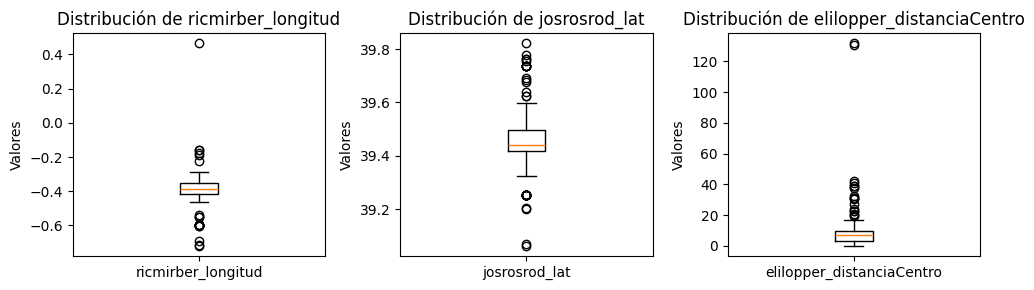

In [206]:
# Valores float
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))

axes = axes.flatten()
for i, var in enumerate(columnas_float):
    axes[i].boxplot(datos[var], tick_labels=[var])
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_ylabel('Valores')

for j in range(len(columnas_float), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### 3.3. Validación de valores int

In [207]:
columnas_int = datos.select_dtypes(include=["int64"]).columns
print(columnas_int)

Index(['josrosrod_dia', 'josrosrod_mes', 'josrosrod_año', 'josrosrod_precio',
       'davsoreng_duplex', 'alegarsal_terraza', 'rafmaralf_baños',
       'samartlop_superficie', 'davroctau_planta', 'juamarxxx_trastero',
       'robripcon_habitaciones', 'omapasvac_ascensor', 'rauramesc_airecentral',
       'guifue_parking'],
      dtype='object')


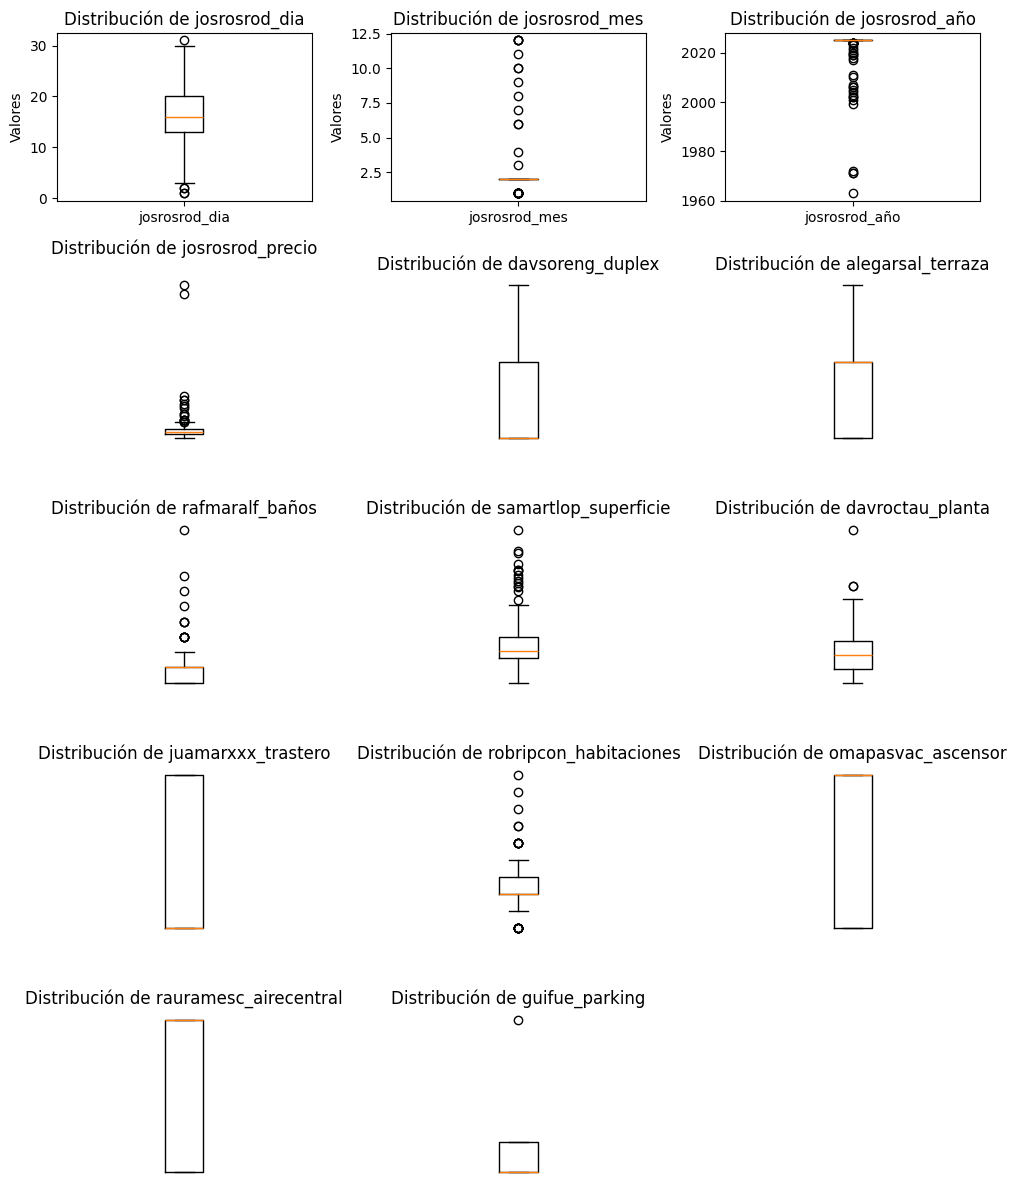

In [208]:
# Valores int
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(10, 12))

axes = axes.flatten()
for i, var in enumerate(columnas_int):
    axes[i].boxplot(datos[var], tick_labels=[var])
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_ylabel('Valores')

for j in range(len(columnas_float), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# 4. Ingeniería de características
## 4.1. Codificación de variables categóricas

In [209]:
datos.head()

,josrosrod_origen,jorosrod_municipio,josrosrod_dia,josrosrod_mes,josrosrod_año,ricmirber_longitud,josrosrod_lat,josrosrod_precio,alvbelnav_iluminacion,davsoreng_duplex,...,rafmaralf_baños,luctarcom_orientacion,samartlop_superficie,davroctau_planta,juamarxxx_trastero,robripcon_habitaciones,omapasvac_ascensor,elilopper_distanciaCentro,rauramesc_airecentral,guifue_parking
0,Fotocasa,Benetuser,16,2,2025,-0.3950,39.4180,140000,Alta,0,...,1,Sureste,81,1,1,3,1,6.0,1,0
1,Fotocasa,Benetuser,16,2,2025,-0.3980,39.4170,85000,Alta,0,...,1,Este,161,1,0,1,0,7.0,1,0
2,Fotocasa,Benetuser,16,2,2025,-0.3987,39.4149,225000,Alta,0,...,2,Este,179,1,1,3,0,6.0,1,0
3,Fotocasa,Benetuser,16,2,2025,-0.3990,39.4145,129999,Alta,0,...,1,Sur,89,2,0,3,1,6.0,0,0
4,Fotocasa,Benetuser,16,2,2025,-0.3985,39.4133,145000,Baja,0,...,1,Oeste,55,1,0,1,1,6.0,1,0


In [210]:
datos.head()

,josrosrod_origen,jorosrod_municipio,josrosrod_dia,josrosrod_mes,josrosrod_año,ricmirber_longitud,josrosrod_lat,josrosrod_precio,alvbelnav_iluminacion,davsoreng_duplex,...,rafmaralf_baños,luctarcom_orientacion,samartlop_superficie,davroctau_planta,juamarxxx_trastero,robripcon_habitaciones,omapasvac_ascensor,elilopper_distanciaCentro,rauramesc_airecentral,guifue_parking
0,Fotocasa,Benetuser,16,2,2025,-0.3950,39.4180,140000,Alta,0,...,1,Sureste,81,1,1,3,1,6.0,1,0
1,Fotocasa,Benetuser,16,2,2025,-0.3980,39.4170,85000,Alta,0,...,1,Este,161,1,0,1,0,7.0,1,0
2,Fotocasa,Benetuser,16,2,2025,-0.3987,39.4149,225000,Alta,0,...,2,Este,179,1,1,3,0,6.0,1,0
3,Fotocasa,Benetuser,16,2,2025,-0.3990,39.4145,129999,Alta,0,...,1,Sur,89,2,0,3,1,6.0,0,0
4,Fotocasa,Benetuser,16,2,2025,-0.3985,39.4133,145000,Baja,0,...,1,Oeste,55,1,0,1,1,6.0,1,0


In [211]:
# Volvemos a obtener las columnas de tipo 'objeto' después de la correción de tipos de las columnas
columnas_object = datos.select_dtypes(include=["object"]).columns

# Codificación de variables
le = LabelEncoder()

for columna in columnas_object:
    print(columna)
    datos[columna] = le.fit_transform(datos[columna])

josrosrod_origen
jorosrod_municipio
alvbelnav_iluminacion
luctarcom_orientacion


In [212]:
datos.head()

,josrosrod_origen,jorosrod_municipio,josrosrod_dia,josrosrod_mes,josrosrod_año,ricmirber_longitud,josrosrod_lat,josrosrod_precio,alvbelnav_iluminacion,davsoreng_duplex,...,rafmaralf_baños,luctarcom_orientacion,samartlop_superficie,davroctau_planta,juamarxxx_trastero,robripcon_habitaciones,omapasvac_ascensor,elilopper_distanciaCentro,rauramesc_airecentral,guifue_parking
0,2,3,16,2,2025,-0.3950,39.4180,140000,0,0,...,1,5,81,1,1,3,1,6.0,1,0
1,2,3,16,2,2025,-0.3980,39.4170,85000,0,0,...,1,0,161,1,0,1,0,7.0,1,0
2,2,3,16,2,2025,-0.3987,39.4149,225000,0,0,...,2,0,179,1,1,3,0,6.0,1,0
3,2,3,16,2,2025,-0.3990,39.4145,129999,0,0,...,1,4,89,2,0,3,1,6.0,0,0
4,2,3,16,2,2025,-0.3985,39.4133,145000,1,0,...,1,3,55,1,0,1,1,6.0,1,0


---
# b) Selección de características

In [213]:
valor_objetivo = "josrosrod_precio"

# Para que la variable objetivo se encuentre al principio del Dataframe
columna_precio = datos[[valor_objetivo]]
datos = datos.drop(valor_objetivo, axis=1)
datos = pd.concat([columna_precio, datos], axis=1)

## Matriz de correlaciones / mapa de calor

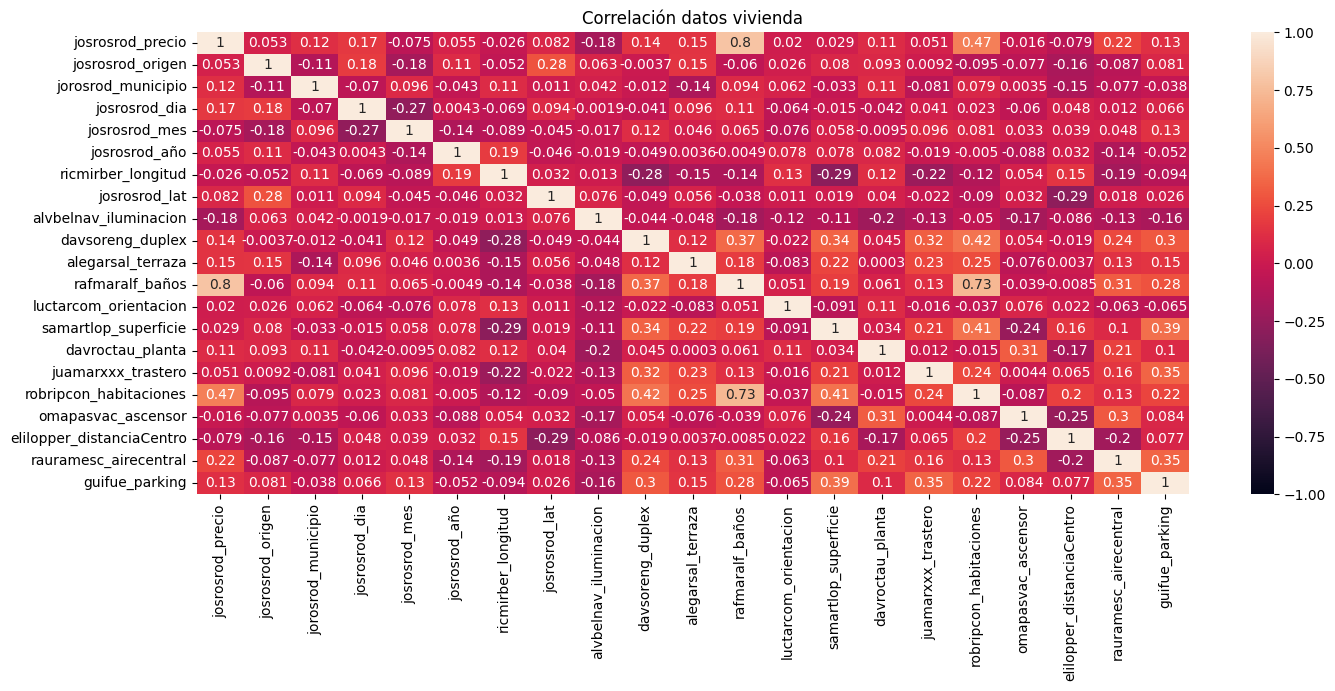

In [214]:
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(datos.corr(), vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlación datos vivienda')

plt.show()

## Estudio estadístico univariado

In [215]:
correlaciones = datos.corr()
correlaciones_objetivo = correlaciones[valor_objetivo].drop(valor_objetivo)
mejores_correlaciones = correlaciones_objetivo.abs().sort_values(ascending=False)

print(mejores_correlaciones)

rafmaralf_baños              0.796238
robripcon_habitaciones       0.466557
rauramesc_airecentral        0.219265
alvbelnav_iluminacion        0.175123
josrosrod_dia                0.166240
alegarsal_terraza            0.146424
davsoreng_duplex             0.140811
guifue_parking               0.131303
jorosrod_municipio           0.117791
davroctau_planta             0.108001
josrosrod_lat                0.082342
elilopper_distanciaCentro    0.079379
josrosrod_mes                0.075330
josrosrod_año                0.055204
josrosrod_origen             0.052629
juamarxxx_trastero           0.050703
samartlop_superficie         0.029032
ricmirber_longitud           0.025879
luctarcom_orientacion        0.019661
omapasvac_ascensor           0.015667
Name: josrosrod_precio, dtype: float64


He decidido conservar las columnas que tienen una relación con el target mayor de 0'06%. Las cuales son las 14 primeras de la lista anterior.

In [216]:
columnas_relevantes_target = list(mejores_correlaciones.head(14).index.values)
datos_relevantes = datos[[valor_objetivo] + columnas_relevantes_target]

## Estudio de colinealidad por parejas

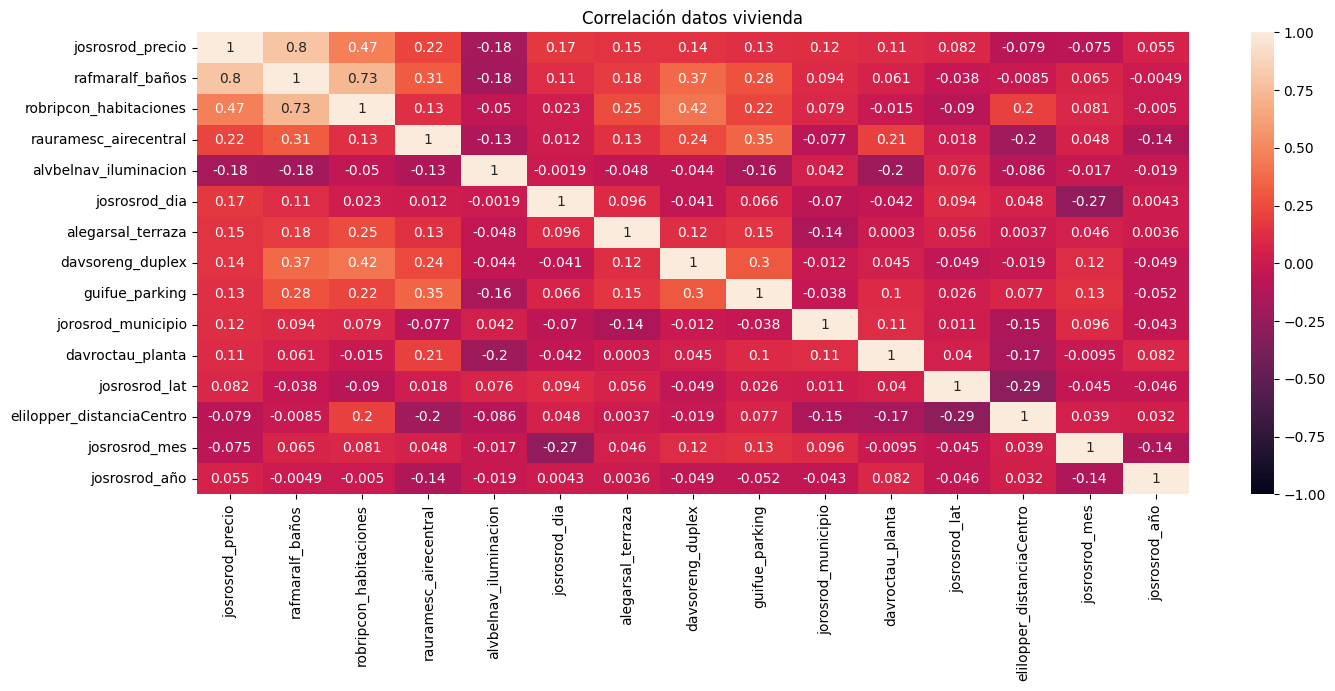

In [217]:
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(datos_relevantes.corr(), vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlación datos vivienda')

plt.show()

He decidido eliminar solamente la predictora 'robripcon_habitaciones' debido a que es la única que tiene una correlación alta (0'73) con otra predictora, en este caso 'rafmaralf_baños'. Entre las dos, he decido eliminar esta primera debido a que es la que tiene menor correlación con el target.

El resto no supera el 0'5, por lo que he decido no eliminar más.

In [218]:
datos_relevantes.drop('robripcon_habitaciones', axis=1)

,josrosrod_precio,rafmaralf_baños,rauramesc_airecentral,alvbelnav_iluminacion,josrosrod_dia,alegarsal_terraza,davsoreng_duplex,guifue_parking,jorosrod_municipio,davroctau_planta,josrosrod_lat,elilopper_distanciaCentro,josrosrod_mes,josrosrod_año
0,140000,1,1,0,16,1,0,0,3,1,39.418000,6.0,2,2025
1,85000,1,1,0,16,0,0,0,3,1,39.417000,7.0,2,2025
2,225000,2,1,0,16,2,0,0,3,1,39.414900,6.0,2,2025
3,129999,1,0,0,16,0,0,0,3,2,39.414500,6.0,2,2025
4,145000,1,1,1,16,1,0,0,3,1,39.413300,6.0,2,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,190000,1,0,2,20,1,0,0,19,0,39.440198,7.6,2,2025
136,185000,1,0,2,5,1,0,0,19,0,39.440198,7.6,2,2025
137,180000,1,0,1,6,0,0,0,19,2,39.440198,7.6,2,2025
138,130000,1,0,2,20,1,0,0,19,4,39.440198,7.6,2,2025


---
# c) Selección de modelos de regresión

In [219]:
# Separar datos en entrenamiento y test
X = datos_relevantes.drop(columns=[valor_objetivo])
y = datos_relevantes[valor_objetivo]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train[columnas_relevantes_target] = scaler.fit_transform(X_train[columnas_relevantes_target])
X_test[columnas_relevantes_target] = scaler.transform(X_test[columnas_relevantes_target])

# Definir modelos
modelos = {
    "Regresión Lineal": LinearRegression(),
    "SGD Regressor": SGDRegressor(max_iter=1000, tol=1e-3, random_state=42),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, warm_start=True),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": XGBRegressor(),
    "RandomForest": RandomForestRegressor(),
    "DecisionTree": DecisionTreeRegressor()
}

# Evaluar modelos
resultados = {}
modelos_entrenados = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    modelos_entrenados[nombre] = modelo

    train_score = modelo.score(X_train, y_train)
    test_score = modelo.score(X_test, y_test)
    resultados[nombre] = {"Train": train_score, "Test": test_score}

# Mostrar resultados
for modelo, scores in resultados.items():
    print(f"\n{modelo}:")
    print(f" - Train score: {scores["Train"]}")
    print(f" - Test score: {scores["Test"]}")


Regresión Lineal:
 - Train score: 0.6003080894385111
 - Test score: 0.757771984036869

SGD Regressor:
 - Train score: 0.5992514128554192
 - Test score: 0.741395461780999

Ridge:
 - Train score: 0.6000880750031521
 - Test score: 0.7482792099483936

Lasso:
 - Train score: 0.6003080894376827
 - Test score: 0.757771628722263

ElasticNet:
 - Train score: 0.5954776554630802
 - Test score: 0.7091957879588758

KNN:
 - Train score: 0.5721156068181343
 - Test score: 0.47619566104670763

XGBoost:
 - Train score: 1.0
 - Test score: 0.9479435682296753

RandomForest:
 - Train score: 0.9283896753943285
 - Test score: 0.8156523263808049

DecisionTree:
 - Train score: 1.0
 - Test score: 0.9409150898692308


---
# d) Estudio de varianza de modelos con CV

In [220]:
resultados = {}
for nombre, modelo in modelos_entrenados.items():    
    cross_val = np.mean(cross_val_score(modelo, X_train, y_train, cv=5))
    resultados[nombre] = {"Cross Val Score": cross_val}


print("Cross validation score (CVS) de cada modelo:")
for modelo, scores in resultados.items():
    print(f" - {modelo}: {scores['Cross Val Score']}")

Cross validation score (CVS) de cada modelo:
 - Regresión Lineal: -0.10115453987974143
 - SGD Regressor: -0.06461165463806946
 - Ridge: -0.052664039641325065
 - Lasso: -0.10115264694692819
 - ElasticNet: 0.06415212864076499
 - KNN: 0.5356667769332821
 - XGBoost: 0.50208899974823
 - RandomForest: 0.06978525331470264
 - DecisionTree: -4.001142391263839


---
# e) Seleccionar los dos que mejor desempeño muestren justificando su elección

He decidido conservar los modelos 'XGBoostRegressor()' y 'DecisionTreeRegressor()' ya que han sido los dos que han obtenido mejores resultados en 'test_score' y de los mejores resultado en CVS.

In [221]:
del modelos_entrenados['Regresión Lineal']
del modelos_entrenados['SGD Regressor']
del modelos_entrenados['Ridge']
del modelos_entrenados['Lasso']
del modelos_entrenados['ElasticNet']
del modelos_entrenados['KNN']
del modelos_entrenados['RandomForest']

print(f"Los dos modelos con mejor desempeño han sido: {modelos_entrenados}")

Los dos modelos con mejor desempeño han sido: {'XGBoost': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...), 'DecisionTree': DecisionTreeRegressor()}


---
# f) Configuración de hiperparámetros con grid-search en los mejores 2 modelos seleccionados

In [222]:
# Definir hiperparámetros a probar
param_grids = {
    'XGBoost': {
        'n_estimators': [100, 300],  
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 6],
        'subsample': [0.8],
        'colsample_bytree': [0.8]
    },
    'DecisionTree': {
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 4, 10], 
        'max_features': ['sqrt', 'log2', None]
    }
}

# Configurar GridSearchCV y obtener resultados
resultados_grid = {}
for nombre, modelo in modelos_entrenados.items():    
    grid_modelo = GridSearchCV(modelo, param_grids[nombre], cv=5, scoring='r2', n_jobs=-1)
    resultados_grid[nombre] = grid_modelo.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros
for nombre, resultados in resultados_grid.items():    
    print(f"\nMejores hiperparámetros para {nombre}: {resultados.best_params_}")
    print(f"Mejor score de validación cruzada para {nombre}: {resultados.best_score_}")



Mejores hiperparámetros para XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
Mejor score de validación cruzada para XGBoost: 0.3772792100906372

Mejores hiperparámetros para DecisionTree: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor score de validación cruzada para DecisionTree: 0.46772138224258447


---
# f) Estudio final de errores en las predicciones y gráfico de importancia de características

MODELO: XGBoost
Train:
 - MAE: 23.6602
 - RMSE: 39.6475
 - R²: 1.0000

Test:
 - MAE: 117255.2190
 - RMSE: 204937.5665
 - R²: 0.9479


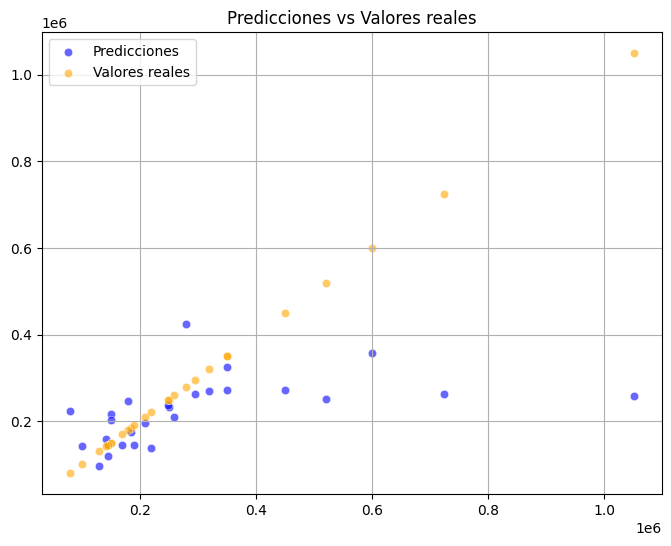

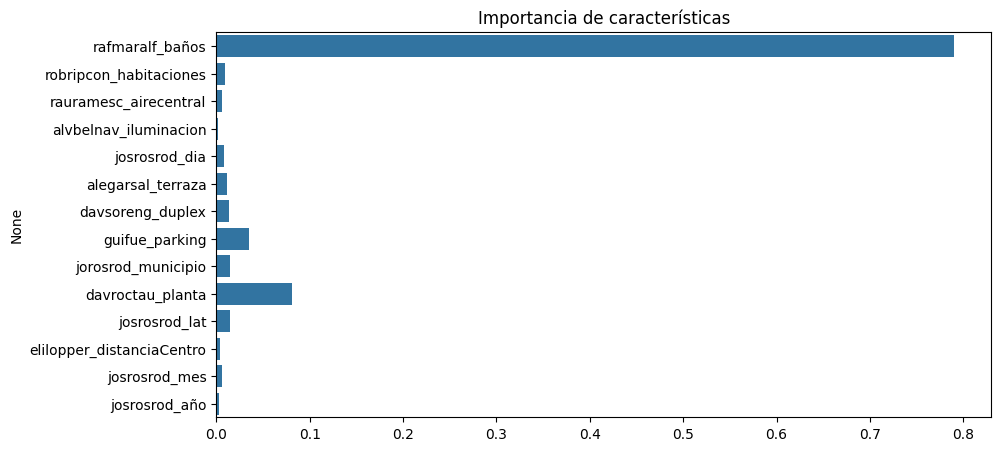

MODELO: DecisionTree
Train:
 - MAE: 0.0000
 - RMSE: 0.0000
 - R²: 1.0000

Test:
 - MAE: 137567.8929
 - RMSE: 218334.5737
 - R²: 0.9409


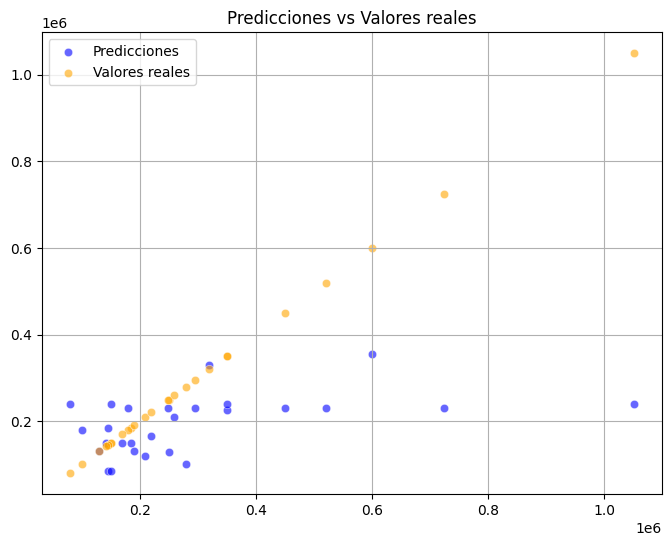

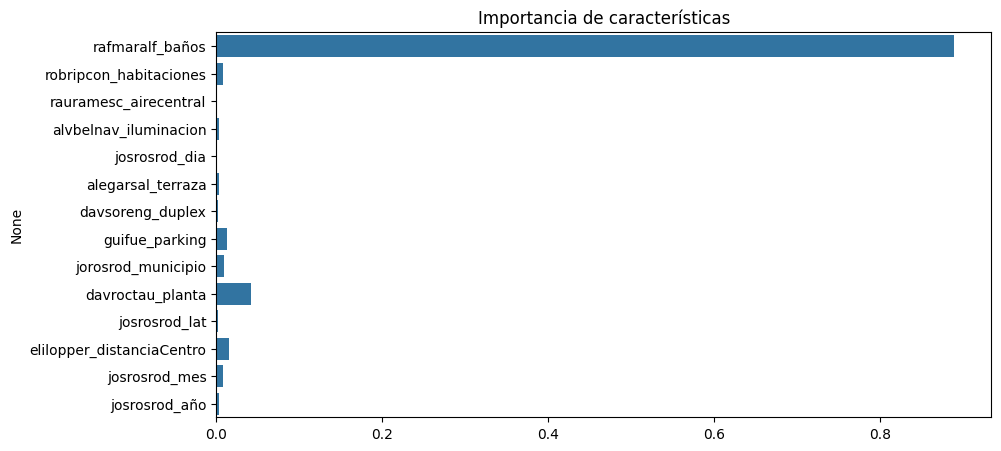

In [223]:
from sklearn.metrics import root_mean_squared_error

# Estudio final de errores en las predicciones y gráfico de importancia de características
def evaluar_modelo(modelo, X_train, y_train, X_test, y_test):
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    
    # Cálculo de métricas
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rmse_train = root_mean_squared_error(y_train, y_train_pred)
    rmse_test = root_mean_squared_error(y_test, y_test_pred)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    print("Train:")
    print(f" - MAE: {mae_train:.4f}")
    print(f" - RMSE: {rmse_train:.4f}")
    print(f" - R²: {r2_train:.4f}")

    print("\nTest:")
    print(f" - MAE: {mae_test:.4f}")
    print(f" - RMSE: {rmse_test:.4f}")
    print(f" - R²: {r2_test:.4f}")
    
    # Filtrado de outliers para que los datos en la gráfica se vean más concentrados
    limite_superior = np.percentile(y_test, 98)
    indices_filtrados = y_test < limite_superior
    y_test_filtrado = y_test[indices_filtrados]
    y_test_pred_filtrado = y_test_pred[indices_filtrados]
    
    # Gráfico de dispersión para visualizar errores
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_test_filtrado, y=y_test_pred_filtrado, color="blue", alpha=0.6, label="Predicciones")
    sns.scatterplot(x=y_test_filtrado, y=y_test_filtrado, color="orange", alpha=0.6, label="Valores reales")
    
    plt.xlabel("")
    plt.ylabel("")
    plt.title("Predicciones vs Valores reales")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Importancia de características
    if hasattr(modelo, 'feature_importances_'):
        importancias = modelo.feature_importances_
        feature_names = X_train.columns
        
        plt.figure(figsize=(10,5))
        sns.barplot(x=importancias, y=feature_names)
        plt.title("Importancia de características")
        plt.show()


for nombre, modelo in modelos_entrenados.items():
    print(f"MODELO: {nombre}")
    evaluar_modelo(modelo, X_train, y_train, X_test, y_test)
    print("================================================================================================")

---
# g) Selección justificada del mejor y su descripción:
 - Qué predictoras utiliza.
 - Una descripción de su utilización y procesos que realiza (preprocesamiento, ...).
 - Qué desempeño alcanza en train y test (indica también la métrica empleada)
 - Una valoración final de tu modelo según los resultados obtenidos.

Entre los dos modelos restantes, he seleccionado como mejor modelo el de `Regresión Lineal`. A pesar de que los resultados de ambos son prácticamente iguales, como tenía que quedarme con uno, he decidido este porque su MAE es un 0'021 menor que el de 'Lasso'.

In [224]:
del modelos_entrenados['DecisionTree']

## Mejor modelo

In [225]:
mejor_modelo_nombre, mejor_modelo = next(iter(modelos_entrenados.items()))
print("\nModelo seleccionado:", mejor_modelo_nombre)


Modelo seleccionado: XGBoost


## Procesos que realiza

- a) **Análisis y preprocesamiento de datos**: gestión de valores nulos, gestión de valores atípicos y codificación de variables categóricas y 

- b) **Selección de cacterísticas**: selección de características relevantes con el target y estudio de colinealidad.
- c) **Selección de modelos de regresión**.
- d) **Estudio de varianza de modelos con CV**.
- e) **Selección de los dos modelos que mejor desempeño muestran**.
- f) **Configuración de hiperparámetros con grid-search en los mejores 2 modelos seleccionados**.
- f (otra vez)) **Estudio final de errores en las predicciones y gráfico de importancia de características**.
- g) **Selección justificada del mejor modelo y descripción**.

## Predictoras que utiliza

In [226]:
print("\nPredictoras utilizadas:")
print(datos_relevantes.columns)


Predictoras utilizadas:
Index(['josrosrod_precio', 'rafmaralf_baños', 'robripcon_habitaciones',
       'rauramesc_airecentral', 'alvbelnav_iluminacion', 'josrosrod_dia',
       'alegarsal_terraza', 'davsoreng_duplex', 'guifue_parking',
       'jorosrod_municipio', 'davroctau_planta', 'josrosrod_lat',
       'elilopper_distanciaCentro', 'josrosrod_mes', 'josrosrod_año'],
      dtype='object')


## Desempeño en train y test

Train:
 - MAE: 23.6602
 - RMSE: 39.6475
 - R²: 1.0000

Test:
 - MAE: 117255.2190
 - RMSE: 204937.5665
 - R²: 0.9479


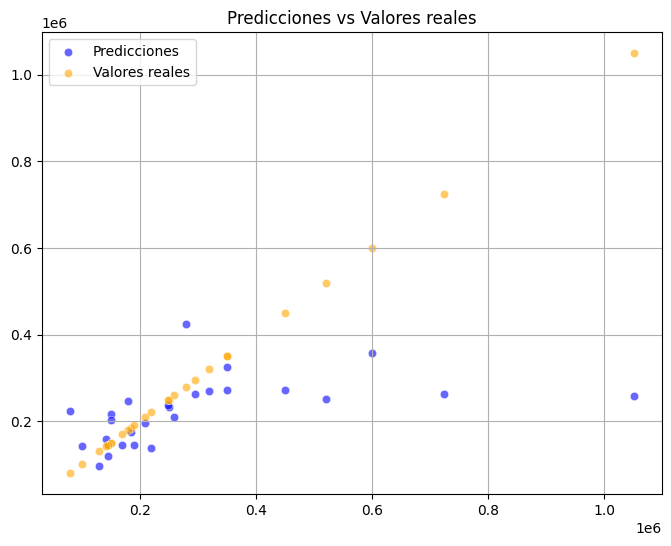

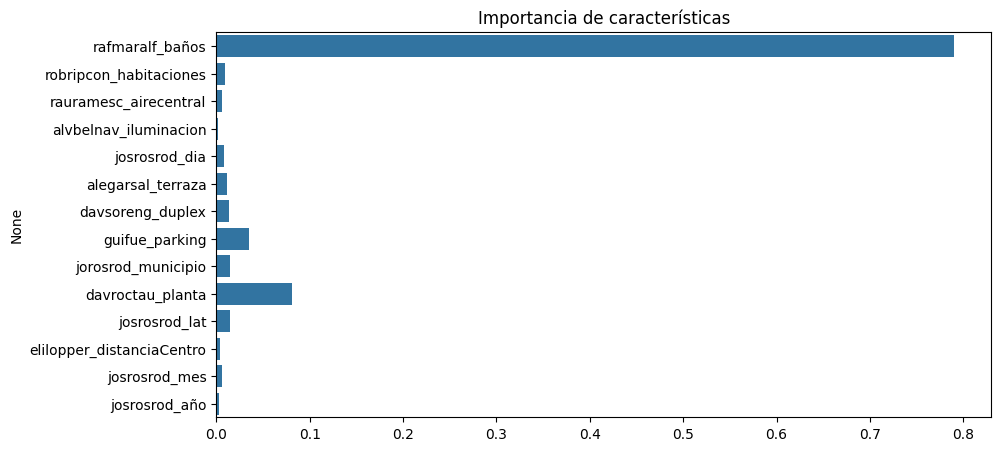

In [227]:
evaluar_modelo(mejor_modelo, X_train, y_train, X_test, y_test)

## **Valoración final del modelo**

A partir de las métricas obtenidas, he llegado a las siguientes conclusiones:

### **1. Sobreajuste muy elevado**
En el conjunto de entrenamiento, el modelo tiene un R2 de 1'0, lo que sugiere que ha memorizado perfectamente los datos de entrenamiento. Sin embargo, en el conjunto de prueba, aunque el R2 sigue siendo alto (0'9479), los errores absolutos (MAE: 117.255'2190) y cuadráticos medios (RMSE: 204.937'5665) son enormes en comparación con los valores del entrenamiento.

### **2. Interpretación de las métricas**
 - MAE (Error Absoluto Medio): el gran aumento de 23'66 en entrenamiento a 117.255 en prueba sugiere que el modelo no generaliza bien con los datos nuevos.
 - RMSE (Raíz del Error Cuadrático Medio): el elevado crecimiento de 39'65 a 204.937 sugiere que hay errores muy grandes en la predicción de algunos valores.
 - R2 (Coeficiente de determinación): aunque 0'9479 es alto, no refleja los elevados errores absolutos. A pesar de que la varianza sea buena, los valores predichos pueden estar alejados de los reales.

### **3. Causas principales del sobreajuste**
 - Datos de entrenamiento insuficientes y poco representativos: como el conjunto de entrenamiento es pequeño y no cubre bien la variabilidad de los datos de prueba, el modelo memoriza en lugar de aprender patrones generales.
 - Modelo demasiado complejo: XGBoost es un modelo potente, por lo que se ajusta demasiado a los datos de entrenamiento.

### **4. Recomendaciones para mejorar el modelo**
 - Recolectar y preprocesar de datos: aumentar la cantidad de datos de base y considerar técnicas como el aumento de datos o la selección de distintas características.
 - Aumento de complejidad: debido a que los datos son demasiado sencillos para el modelo, sería conveniente añadir más columnas para incrementar la complejidad de los mismos.

### **Resumen**
El modelo tiene un sobreajuste demasiado elevado, con un rendimiento perfecto en entrenamiento pero errores enormes en prueba, por lo tanto sería totalmente inutilizable en una situación real debido a su mal desempeño. El motivo principal es la poca cantidad de datos, por lo que sería conveniente aumentar esta cantidad en gran medida antes de volver a entrenar el modelo.

# h) Guarda el modelo en un fichero con el nombre "iniciales"_modelo_u02_p03_a3.joblib donde "iniciales" son las 3 primeras letras del nombre y apellidos, en mi caso sería "josrosrod_modelo_u02_p03_a3.joblib"

In [228]:
dump(mejor_modelo, 'davroctau_modelo_u02_p03_a3.joblib')

['davroctau_modelo_u02_p03_a3.joblib']